# Instrukcja użytkowania

In [1]:
# Instalacja najnowszych wersji bibliotek
#!pip install -q git+https://github.com/huggingface/transformers.git
#!pip install -q torch torchvision pillow requests
print(';)')

;)


In [2]:
import torch
import requests
from PIL import Image
from transformers import AutoImageProcessor, AutoTokenizer, AutoModel
from dotenv import load_dotenv

load_dotenv()
import os

HF_TOKEN = os.getenv("HF_TOKEN")

# Wybór silnika: GPU (cuda) jest zalecane, na CPU model będzie działał bardzo wolno
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "facebook/metaclip-2-worldwide-giant-378"

print(f"Ładowanie procesorów i modelu na: {device}...")

# 1. ImageProcessor: Zmienia rozmiar obrazu na 378x378 i normalizuje kolory
image_processor = AutoImageProcessor.from_pretrained(model_id, token = HF_TOKEN if HF_TOKEN else None)

# 2. Tokenizer: Zamienia słowa na liczby (ID), które rozumie sieć neuronowa
tokenizer = AutoTokenizer.from_pretrained(model_id, token = HF_TOKEN if HF_TOKEN else None)

# 3. Model: Ładujemy 4 miliardy parametrów w formacie bfloat16 (oszczędność RAM)
model = AutoModel.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    attn_implementation="sdpa",
    token = HF_TOKEN if HF_TOKEN else None
).to(device)

Ładowanie procesorów i modelu na: cuda...


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1294 [00:00<?, ?it/s]

In [3]:
# Pobranie obrazka testowego (koty na kanapie)
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# Lista etykiet, które model ma sprawdzić
labels = ["a photo of a cat", "a photo of a dog", "a photo of a car"]

# Przetwarzanie na tensory (format zrozumiały dla PyTorch)
image_inputs = image_processor(images=image, return_tensors="pt").to(device)
text_inputs = tokenizer(text=labels, padding=True, return_tensors="pt").to(device)

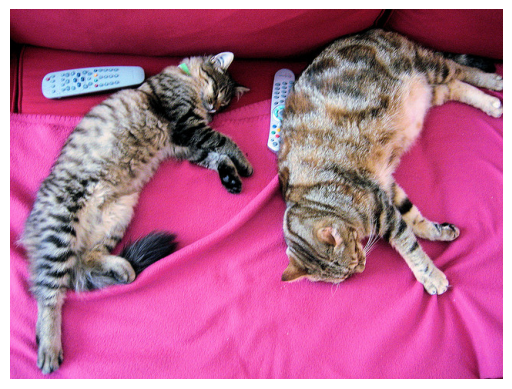

In [9]:
import matplotlib.pyplot as plt

# Wizualizacja obrazka
plt.imshow(image)
plt.axis("off")
plt.show()

## Sprawdzanie jak działa oryginalny model

In [4]:
with torch.no_grad(): # Wyłączamy zapamiętywanie gradientów (oszczędza pamięć)
    outputs_base = model(
        input_ids=text_inputs.input_ids,
        attention_mask=text_inputs.attention_mask,
        pixel_values=image_inputs.pixel_values
    )

# Obliczenie prawdopodobieństwa
probs_base = outputs_base.logits_per_image.softmax(dim=1)[0]

print("\n--- WYNIK BAZOWY (BEZ INGERENCJI) ---")
for label, prob in zip(labels, probs_base):
    print(f"{label}: {prob.item():.4f}")


--- WYNIK BAZOWY (BEZ INGERENCJI) ---
a photo of a cat: 0.9961
a photo of a dog: 0.0041
a photo of a car: 0.0001


## Modyfikacja działania modelu

In [5]:
# Funkcja-szpieg, która przechwytuje i modyfikuje dane w locie
def modify_activation_hook(module, inputs, output):
    # Sprawdzamy, czy output to krotka (niektóre warstwy zwracają dodatkowe dane)
    is_tuple = isinstance(output, tuple)
    hidden_states = output[0] if is_tuple else output

    print(f"[HOOK] Przechwycono aktywacje warstwy. Kształt: {hidden_states.shape}")

    # MODYFIKACJA: Zerujemy wszystkie wartości w tej warstwie
    modified_hidden_states = hidden_states * 0.0

    if is_tuple:
        return (modified_hidden_states,) + output[1:]
    return modified_hidden_states

# Wybieramy cel: 20. warstwa kodera obrazu (Vision Encoder)
layer_to_hack = model.vision_model.encoder.layers[20]

# "Instalujemy" hak na stałe do wybranej warstwy
hook_handle = layer_to_hack.register_forward_hook(modify_activation_hook)

## Sprawdzanie działania zmodyfikowanego modelu

In [6]:
print("\n--- URUCHAMIAMY MODEL Z MODYFIKACJĄ ---")
with torch.no_grad():
    outputs_modified = model(
        input_ids=text_inputs.input_ids,
        attention_mask=text_inputs.attention_mask,
        pixel_values=image_inputs.pixel_values
    )

hook_handle.remove() # w naszym przypadku nie jest to konieczne działanie

# Porównanie wyników
probs_modified = outputs_modified.logits_per_image.softmax(dim=1)[0]
print("\n--- WYNIK PO ZEROWANIU WARSTWY 20 ---")
for label, prob in zip(labels, probs_modified):
    print(f"{label}: {prob.item():.4f}")


--- URUCHAMIAMY MODEL Z MODYFIKACJĄ ---
[HOOK] Przechwycono aktywacje warstwy. Kształt: torch.Size([1, 730, 1664])

--- WYNIK PO ZEROWANIU WARSTWY 20 ---
a photo of a cat: 0.4258
a photo of a dog: 0.3320
a photo of a car: 0.2422


In [7]:
len(model.vision_model.encoder.layers)

48